# Project 1 Celebrity ID
## Task: Claim One Unique CelebA Identity ID

**IE 7615** - Project 1 Task 1

**David Fung**

There are 15 students in the class, so each student will claim one unique identity ID from the CelebA dataset. No two students should claim the same identity ID.

Dataset: celeba-dataset

How to select your identity:

1. CelebA does not provide celebrity names in the identity file. Instead, each image is associated with an identity ID in identity_CelebA.txt.
2. You must run the necessary code to count the number of images associated with each identity ID and identify eligible IDs.
3. For this milestone, select an identity ID that has 23–25 images in the CelebA dataset.

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

In [3]:
# PROJECT CONSTANTS
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

PROJECT_ROOT  = Path("..", "..").resolve()

IDENTITY_FILE = PROJECT_ROOT / "IE7615" / "Project_1" / "data" / "identity_CelebA.txt"
IMG_DIR = PROJECT_ROOT / "IE7615" / "Project_1" / "data" / "celeb" / "img_align_celeba" / "img_align_celeba"

MIN_IMAGES, MAX_IMAGES = 23, 25

## Task 1 Prepare the Data

In [4]:
# Check file links all work

print("Identity file : " + str(IDENTITY_FILE))
print("Image folder  : " + str(IMG_DIR) + "  (exists: " + str(IMG_DIR.exists()) + ")")
print("Eligible range: " + str(MIN_IMAGES) + "-" + str(MAX_IMAGES) + " images per identity")

Identity file : \\PEMBROKE\davidfung\Education\Northeastern\MS_DAE\IE7615\Project_1\data\identity_CelebA.txt
Image folder  : \\PEMBROKE\davidfung\Education\Northeastern\MS_DAE\IE7615\Project_1\data\celeb\img_align_celeba\img_align_celeba  (exists: True)
Eligible range: 23-25 images per identity


In [5]:
def resolve_img(name):
    p = Path(name)
    if p.is_absolute():
        return str(p)
    return str(IMG_DIR / name)

def show_identity_images(paths, title, cols=5):
    n = len(paths)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.atleast_1d(axes).flatten()
    for i, p in enumerate(paths):
        try:
            axes[i].imshow(Image.open(p).convert("RGB"))
        except (FileNotFoundError, OSError):
            axes[i].text(0.5, 0.5, "missing", ha="center", va="center")
        axes[i].set_title(os.path.basename(p), fontsize=8)
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

Total images        : 202,599
Total identities    : 10,177


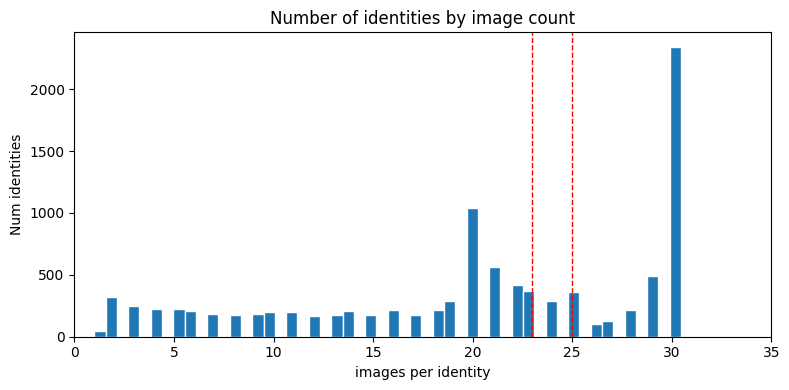

In [6]:
# Create the DF to count the number of images

records = []
with open(IDENTITY_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        img_name  = parts[0]
        identity_id = next((t for t in parts if t.lstrip("-").isdigit()), None)
        records.append({"identity_id": int(identity_id),
                        "image_name": img_name,
                        "image_path": resolve_img(img_name)})

df = pd.DataFrame(records)
counts = df["identity_id"].value_counts().sort_index()

print("Total images        : " + format(len(df), ","))
print("Total identities    : " + format(counts.shape[0], ","))

# Quick histogram of the distribution, so we can see the 23-25 band
plt.figure(figsize=(8, 4))
plt.hist(counts, bins=60, edgecolor="white")
plt.axvline(MIN_IMAGES, color="red", ls="--", lw=1)
plt.axvline(MAX_IMAGES, color="red", ls="--", lw=1)
plt.title("Number of identities by image count")
plt.xlabel("images per identity")
plt.ylabel("Num identities")
plt.xlim(0, min(60, counts.max()))
plt.tight_layout(); plt.show()

## Task 2 - List the Eligible Identities (23-25 images)

Filter the identities whose image count falls in the eligible range. Any one of these is a suitable, well-balanced class for the classifier.

In [7]:
eligible = counts[(counts >= MIN_IMAGES) & (counts <= MAX_IMAGES)].sort_index()

print("Identities with " + str(MIN_IMAGES) + "-" + str(MAX_IMAGES) + " images : " + format(eligible.shape[0], ","))

table = eligible.to_frame("image_count").sort_values("image_count")
ids = ", ".join(map(str, eligible.index.tolist()))
print("Eligible identity IDs: " + ids)

Identities with 23-25 images : 1,020
Eligible identity IDs: 3, 6, 7, 12, 28, 39, 41, 46, 48, 52, 53, 58, 67, 73, 77, 86, 98, 106, 110, 117, 119, 129, 137, 141, 148, 151, 156, 158, 165, 167, 170, 173, 195, 218, 224, 229, 258, 264, 279, 281, 288, 302, 315, 357, 364, 383, 385, 391, 410, 414, 415, 418, 420, 422, 427, 455, 482, 489, 497, 500, 509, 519, 528, 530, 535, 548, 549, 583, 584, 596, 607, 610, 619, 633, 643, 644, 646, 648, 652, 654, 666, 672, 689, 693, 696, 716, 718, 721, 724, 734, 739, 744, 749, 750, 756, 759, 774, 780, 797, 804, 819, 824, 825, 831, 834, 839, 854, 855, 865, 866, 874, 881, 885, 887, 895, 896, 898, 915, 926, 927, 931, 936, 939, 945, 952, 957, 960, 963, 974, 1002, 1013, 1022, 1028, 1036, 1046, 1048, 1056, 1068, 1081, 1093, 1117, 1125, 1148, 1150, 1158, 1160, 1171, 1173, 1206, 1208, 1211, 1212, 1225, 1240, 1241, 1243, 1249, 1263, 1266, 1283, 1285, 1292, 1299, 1312, 1313, 1317, 1333, 1340, 1347, 1358, 1365, 1390, 1391, 1398, 1405, 1424, 1425, 1437, 1441, 1442, 1445, 145

## Task 3 - Pick One Identity and View Its Images

Choose **one** eligible identity ID (copy one from the list above) and set
`SELECTED_ID` to it.  The cell below loads and displays every image for that
identity so we can confirm it is one person and that the crops look clean.

Identity 4428: 23 images


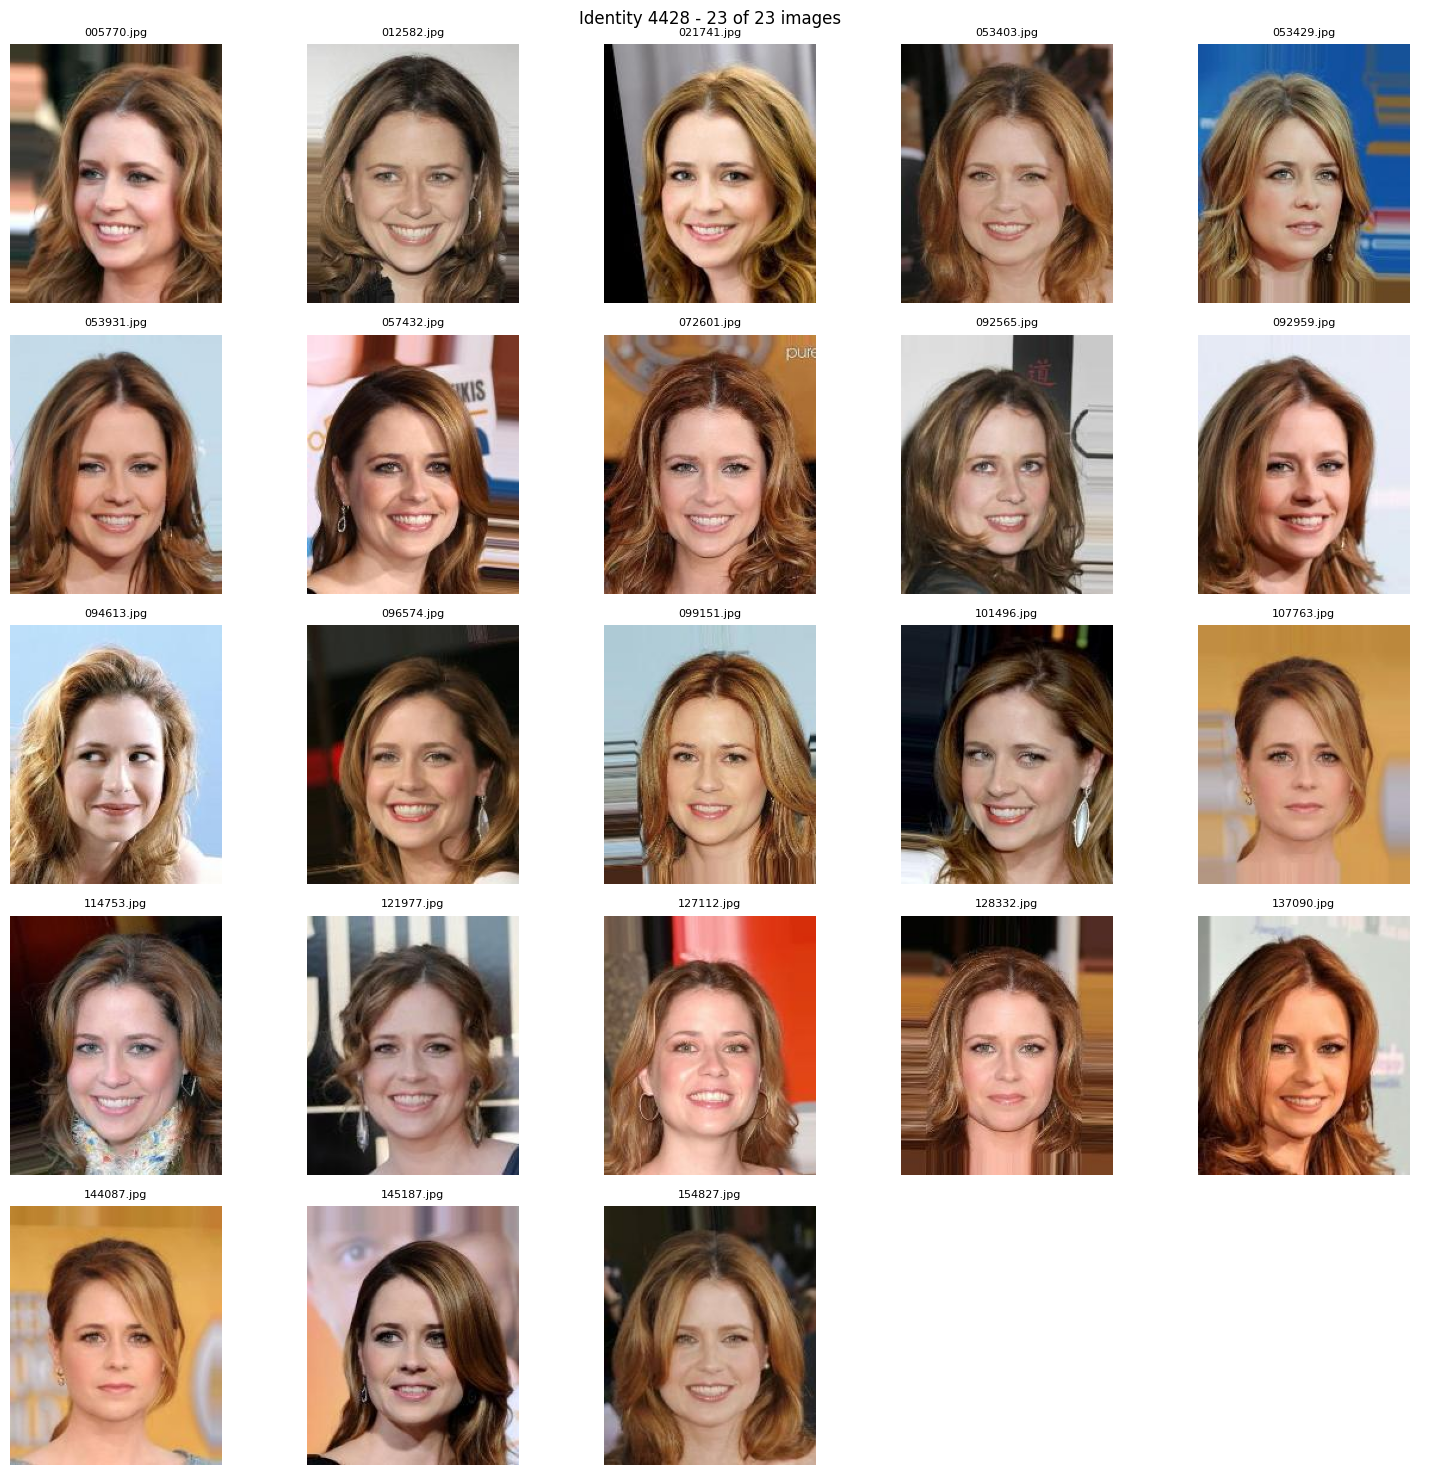

In [8]:
SELECTED_ID = 4428

sel = df[df["identity_id"] == SELECTED_ID]
paths = sel["image_path"].tolist()

print("Identity " + str(SELECTED_ID) + ": " + str(len(paths)) + " images")

show_identity_images(paths[:25],
                     "Identity " + str(SELECTED_ID) + " - " +
                     str(min(len(paths), 25)) + " of " + str(len(paths)) + " images")

## Task 4

Save the files to disk

In [10]:
import shutil
from pathlib import Path

out_dir = PROJECT_ROOT / "IE7615" / "Project_1" / "data" / f"selected_{SELECTED_ID}"
out_dir.mkdir(parents=True, exist_ok=True)

collected = []
with open(IDENTITY_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        identity_id = next((t for t in parts if t.lstrip("-").isdigit()), None)
        if identity_id is None:
            continue
        if int(identity_id) != SELECTED_ID:
            continue

        src = IMG_DIR / parts[0]
        if src.exists():
            shutil.copy2(src, out_dir / src.name)
            collected.append(src.name)
        else:
            print("  missing:", src)

print(f"Identity {SELECTED_ID}: {len(collected)} images copied to {out_dir}")
for name in collected:
    print("  " + name)

Identity 4428: 23 images copied to \\PEMBROKE\davidfung\Education\Northeastern\MS_DAE\IE7615\Project_1\data\selected_4428
  005770.jpg
  012582.jpg
  021741.jpg
  053403.jpg
  053429.jpg
  053931.jpg
  057432.jpg
  072601.jpg
  092565.jpg
  092959.jpg
  094613.jpg
  096574.jpg
  099151.jpg
  101496.jpg
  107763.jpg
  114753.jpg
  121977.jpg
  127112.jpg
  128332.jpg
  137090.jpg
  144087.jpg
  145187.jpg
  154827.jpg
